In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import subprocess as sub
import time
from scipy.optimize import differential_evolution
from matplotlib import colors
#plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use('default')
G = 6.6742e-8
C = 2.99792458e10
Msun = 1.9891e33

In [34]:
N_spins = 12
N_dens = 20
#r_ratios = np.linspace(0.99, 0.75, N_spins)
r_ratios = np.log10(np.linspace(9.9, 6, N_spins))
eoss = np.array(pd.read_csv('../compose/max_dens.csv', header=None))
eos_names = eoss[:,0]
min_dens = eoss[:,1]
max_dens = eoss[:,2]

In [40]:
sub.run('make quasik')

CompletedProcess(args='make quasik', returncode=0)

In [10]:
incl = 90
obl = 0.898196
sub.run('./quasik.exe -f "../compose/eosABPR1" -e 1.209e15 -r ' + str(obl) + ' -i ' + str(incl) + ' -p 10', capture_output=True)

CompletedProcess(args='./quasik.exe -f "../eos/eosABPR1" -e 1.209e15 -r 0.898196 -i 90 -p 10', returncode=0, stdout=b'EOS file: ../eos/eosABPR1, Grid size = MDIVxSDIV = 151x301\r\n\r\ne_center = 1.209e15 g/cm^3\r\nr_ratio  = 0.898196\r\nMass     = 1.79476 MSUN\r\nM/R      = 0.222105 \r\nR_e      = 11.9361 km\r\nSpin     = 745.439 Hz\r\nj = a/M  = J/M^2 = 0.336268 \r\n\r\nQuadrupole: Laarakkers and Poisson \r\nQuadrupole = -7.73896e+43 g cm^2 \r\nqscale = -0.308446 \r\nmscale = -0.329076 \r\nLP formula: q = -0.486228 \r\nQuasiKerr dimensionless quadrupole parameter: epsilon = 0.195369 \r\n\r\nComparison of QuasiKerr Metric with numerical RNS metric\r\nOmega = 4683.728727, Omega_K = 11691.362629\r\n', stderr=b'')

In [74]:
MDIV = 150
cols = 6

mapdata = np.array(pd.read_csv('zmap.csv', header=None)).reshape([2*MDIV, MDIV, cols])
theta = np.arccos(mapdata[:,:,0])
phi = mapdata[:,:,1]
zos = mapdata[:,:,2]
zcon = mapdata[:,:,3]
zqk = mapdata[:,:,4]
zqkb = mapdata[:,:,5]

cmap = plt.cm.coolwarm
cmap.set_bad(color='w')

In [56]:
def zmap(zmap, vmin=None, vmax=None):

    z_mask = np.ma.masked_where(zmap == 0, zmap).transpose()

    if vmin==None:
        vmin = zmap.min()
    if vmax==None:
        vmax = zmap.max()

    plt.figure()
    plt.pcolormesh(phi.transpose(), theta.transpose(), z_mask, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.errorbar([np.pi/2, -np.pi/2], [np.pi/2, np.pi/2], xerr=np.pi/2, yerr=np.pi/2, c='k', lw=0.4)
    plt.gca().invert_yaxis()
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$\phi$")
    plt.colorbar(label="z")

In [ ]:
zmap(zos)
zmap(zcon)
zmap(zqk)
zmap(zqkb)

In [ ]:
i_0 = np.where(zos != 0)
zerr_fill = (np.abs((zcon[i_0]-zqkb[i_0])/(zcon[i_0]+1)))*100
zerr = np.zeros(zos.shape)
zerr[i_0] = zerr_fill

zmap(zerr)

In [35]:
def zmap_3d(zmap, vmin=None, vmax=None):

    z_mask = np.ma.masked_where(zmap == 0, zmap)

    if vmin==None:
        vmin = zmap.min()
    if vmax==None:
        vmax = zmap.max()

    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    z_mask = norm(z_mask)

    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    fig = plt.figure(figsize=plt.figaspect(obl)*2)
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(x, y, z, rcount=2*MDIV+1, ccount=2*MDIV+1, facecolors=cmap(z_mask), shade=False)
    ax.view_init(elev=90-incl, azim=0)
    ax.axis("off")
    mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    mappable.set_array(z_mask)
    fig.colorbar(mappable, shrink=0.5, ax=ax)
    ax.set_box_aspect(aspect=(1, 1, obl))
    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    plt.xlabel("x")
    plt.ylabel("y")

In [ ]:
zmap_3d(zos)
zmap_3d(zcon)
zmap_3d(zqk)
zmap_3d(zqkb)

In [11]:
redshifts = np.array(pd.read_csv('redshift.csv'))

mu = redshifts[:,0]

z_0 = redshifts[:,1]
z_max = redshifts[:,2]
z_min = redshifts[:,3]

z_sch = redshifts[:,4]
z_grav = redshifts[:,5]

z_os_0 = redshifts[:,6]
z_os_max = redshifts[:,7]
z_os_min = redshifts[:,8]
gamma = redshifts[:,9]

z_schv = 1/redshifts[:,10]-1
z_ker = 1/redshifts[:,11]-1
z_quk = 1/redshifts[:,12]-1
z_quk_bad = 1/redshifts[:,13]-1

In [ ]:
fig, ax = plt.subplots()
ax.plot(mu, z_0, c='k', alpha=0.3, lw=3, label='RNS')
#ax.plot(mu, z_sch, c='m', alpha=0.7, label='Schwarzschild')
#ax.plot(mu, z_grav, c='c', alpha=0.7, label='$ RNS \ g_{tt}$')
ax.plot(mu[:-1], z_os_0[:-1], c='b', alpha=0.7, label='Oblate Schwarzschild')
#ax.plot(mu, z_schv, c='brown', alpha=0.7, label='$Sch/\gamma$')
ax.plot(mu, z_ker, c='g', alpha=0.7, label='Kerr')
ax.plot(mu, z_quk, c='r', alpha=1, lw=2.2, linestyle=':', label='Quasikerr')
ax.plot(mu, z_quk_bad, c='orange', alpha=1, lw=1, linestyle='--', label='Incorrect Quasikerr')
plt.xlabel(r"$\cos\theta$")
plt.ylabel('z')
#ax.set_ylim(0, 0.3)
ax.legend(loc='best')
#plt.savefig('output.png', dpi=390)

In [ ]:
plt.plot(mu, (z_0-z_quk)/z_0)

In [ ]:
fig, ax = plt.subplots()
ax.plot(mu, z_0, c='k', alpha=0.7, label='RNS b=0')
ax.plot(mu, z_max, c='b', alpha=0.7, label='RNS b=b_max')
ax.plot(mu, z_min, c='r', alpha=0.7, label='RNS b=b_min')
ax.plot(mu, z_os_0, c='pink', alpha=0.7, label='Obl Sch b=0')
ax.plot(mu, z_os_max, c='c', alpha=0.7, label='Obl Sch b=b_max')
ax.plot(mu, z_os_min, c='orange', alpha=0.7, label='Obl Sch b=b_min')
plt.xlabel(r'$\cos\theta$')
plt.ylabel('z')
#ax.set_ylim(0, 0.3)
ax.legend()

In [ ]:
plt.plot(mu, np.abs((z_0-z_os_0)/(z_0+1))*100)
plt.plot(mu, np.abs((z_max-z_os_max)/(z_max+1))*100)
plt.plot(mu, np.abs((z_min-z_os_min)/(z_min+1))*100)

In [40]:
class Eos_Set():

    def __init__(self, eos_name):

        self.name = eos_name
        self.data = np.load("star_data_"+eos_name+'.npy')
        
    def z_model(self, M_R, spin, C):

        return 1/np.sqrt(1-2*M_R)*(1+C*spin**2)-1

    def C(self, M_R, c1):

        return 1/2*M_R*(1+c1*M_R)

    def z_total(self, i_r):

        M_R = self.data[:, i_r, 4]
        z_total = self.data[:, i_r, 6]

        return [M_R, z_total]
    
    def z_empirical(self, i_r, c1):

        M_R = self.data[:, i_r, 4]
        spins = self.data[:, i_r, 5]
        z_emp = self.z_model(M_R, spins, self.C(M_R, c1))

        return [M_R, z_emp]
    
    def z_quad(self, i_r):

        M_R = self.data[:, i_r, 4]
        a = self.data[:, i_r, 8]
        eps = self.data[:, i_r, 9]

        omega = self.data[:, i_r, 1]
        R = self.data[:, i_r, 2]/100
        V = omega*R/C

        q = -eps-a**2

        z_q = 1/np.sqrt(1-2*M_R)*(1-q*M_R**3)-1

        return z_q
    
    def filter_index(self, i_r):

        massrange = np.array([0.9, 2.4])*Msun
        #spinrange = 800*2*np.pi
        mrrange = np.array([0.05, 1])

        indices = np.where(
        (self.data[:, i_r, 3] > massrange[0]) & 
        (self.data[:, i_r, 3] < massrange[1]) & 
        #(self.data[:, i_r, 1] < spinrange) & 
        (self.data[:, i_r, 4] > mrrange[0]) &
        (self.data[:, i_r, 4] < mrrange[1])
        )[0]
        indices = np.unique(indices)
        indices.sort()
        return indices.astype(int)
    
    def test_fit(self, c1, filter=True, show=False):

        if show:
            filter = False

        redshift_error = np.empty([0])

        for j in range(6):

            i_ = range(N_dens)
            if filter:
                i_ = self.filter_index(j)
            z_t = self.data[i_, j, 6]
            mr = self.data[i_, j, 4]
            spn = self.data[i_, j, 5]
            z_e = self.z_model(mr, spn, self.C(mr, c1))

            z_err = np.abs(z_e-z_t)/(1+z_t)

            redshift_error = np.concatenate([redshift_error, z_err])

        residual = np.sum(redshift_error**2)

        if (show):

            M_R = np.zeros(N_dens+1)
            M_R[1:] = self.data[:, 5, 4]
            r_r = np.zeros(N_spins+1)
            r_r[0] = 1
            r_r[1:] = r_ratios

            plt.figure()
            plt.pcolormesh(M_R, r_r, redshift_error.transpose()*100, cmap='plasma', vmin=0, shading='flat')
            plt.colorbar(label='squared residual')
            plt.xlabel('$M/R$')
            plt.ylabel('$r_{e}/r_{p}$')
            plt.title("eos"+self.name)
            plt.show()

            print("error = "+str(residual))

        return residual

    def plot_fit(self, c1, i_r):

        M_R = self.data[:, i_r, 4]
        spins = self.data[:, i_r, 5]
        z_total = self.data[:, i_r, 6]
        z_emp = self.z_model(M_R, spins, self.C(M_R, c1))
        a = self.data[:, i_r, 8]
        eps = self.data[:, i_r, 9]

        q = -eps-a**2

        z_q = self.z_quad(i_r)

        skip = 2
        plt.figure()
        plt.plot(M_R[skip:], z_total[skip:], c='r', alpha=0.7, label='total redshift')
        plt.plot(M_R[skip:], z_emp[skip:], c='g', alpha=0.5, label='empirical redshift')
        plt.plot(M_R[skip:], z_q[skip:], c='m', alpha=0.7, label='q redshift')
        plt.xlabel('$M/R$')
        plt.ylabel('z_eq')
        plt.title("eos "+self.name+", $r_e/r_p = $"+str(r_ratios[i_r]))
        plt.legend()
        plt.show()
    
    def fit_LSQ(self):

        x = np.empty([0])
        y = np.empty([0])

        for i_r in range(N_spins):
            
            i_ = self.filter_index(i_r)
            mr = self.data[i_, i_r, 4]
            spn = self.data[i_, i_r, 5]
            z = self.data[i_, i_r, 6]

            xfill = mr.transpose()
            yfill = (1/spn**2)*((1+z)*np.sqrt(1-2*mr)-1)/(1/2*mr)-1

            x = np.concatenate([x, xfill])
            y = np.concatenate([y, yfill])


        xT = np.transpose(x)
        xTx = np.dot(xT, x)
        xTxinv = np.linalg.inv(xTx)
        A = np.dot(xTxinv, xT)
        coefs = np.dot(A, y)
        
        return coefs
    
    def bruteforce(self):
        steps = 50
        c1_range = np.linspace(0, 3, steps)
        c2_range = np.linspace(0, 1, steps)
        fit_errors = np.zeros([steps, steps])

        for ic1 in range(steps):
            for ic2 in range(steps):
                fit_errors[ic1, ic2] = self.test_fit(c1_range[ic1], c2_range[ic2])
        min = fit_errors.min()
        indices = np.where(fit_errors == min)
        c1 = c1_range[indices[0]][0]
        c2 = c2_range[indices[1]][0]
        coefs = np.array([c2, c1])

        plt.figure()
        plt.imshow(fit_errors)
        plt.xlabel('c1 from 0 to 3')
        plt.ylabel('c2 from 0 to 1')
        plt.colorbar(label='residuals')

        return coefs
    
    def diff_evo_obj(self, params):

        c1 = params
        return self.test_fit(c1)
    
    def diff_evo(self):

        bounds = [(-5, 5),]
        result = differential_evolution(self.diff_evo_obj, bounds)
        c1 = result.x
        coefs = np.array([c1])

        return coefs 

    def plot_quad_(self, i_r, eta=3.3):

        M = self.data[self.filter_index(i_r), i_r, 3]
        #R = self.data[self.filter_index(i_r), i_r, 2]
        M_R = self.data[self.filter_index(i_r), i_r, 4]
        #quad = self.data[self.filter_index(i_r), i_r, 7]
        a = self.data[self.filter_index(i_r), i_r, 8]
        eps = self.data[self.filter_index(i_r), i_r, 9]

        q = -eps-a**2
        
        quad_corr = a**2*(1+eta)

        skip = 0
        plt.figure()
        plt.plot(M[skip:]/Msun, quad_corr[skip:], label='$a^2(1+3.3)$ ')#+str(r_ratios[i_r]))
        plt.plot(M[skip:]/Msun, -q[skip:], label='q ')#+str(r_ratios[i_r]))
        
        plt.xlabel('$M/M_\odot$')
        plt.ylabel('dimensionless q')
        plt.title("eos "+self.name+", $r_p/r_e$ = "+str(r_ratios[i_r]))
        plt.legend()

        plt.show()

    def plot_quad(self, i_r):

        M = self.data[self.filter_index(i_r), i_r, 3]
        M_R = self.data[self.filter_index(i_r), i_r, 4]
        a = self.data[self.filter_index(i_r), i_r, 8]
        eps = self.data[self.filter_index(i_r), i_r, 9]
        spn = self.data[self.filter_index(i_r), i_r, 5]

        q = -eps-a**2

        skip = 0
        plt.figure()
        plt.plot(M_R[skip:], -q[skip:], label='q')#+str(r_ratios[i_r]))
        plt.plot(M_R[skip:], (self.C(M_R, 1.3, 0.5)*M_R**(-3)*spn**2)[skip:], label='approx')
        
        plt.xlabel('$M/R$')
        plt.ylabel('q')
        plt.title("eos "+self.name+", $r_p/r_e$ = "+str(r_ratios[i_r]))
        plt.legend()

        plt.show()

In [41]:
Eos_array = np.empty(eos_names.size, dtype=object)

for j in range(eos_names.size):

    Eos_array[j] = Eos_Set(eos_names[j])

Eos_real = np.empty(16, dtype=object)

for j in range(16):

    Eos_real[j] = Eos_Set(eos_names[j])

Eos_poly = np.empty(10, dtype=object)

for j in range(10):

    Eos_poly[j] = Eos_Set(eos_names[j+16])

In [ ]:
for Eos in Eos_array:

    #Eos.plot_fit(1.16, 0.52, 4)
    Eos.plot_quad_(1, 3.3)

In [ ]:
res_ls = 0
res_de = 0

for Eos in Eos_array:
    try:
        coefs_ls = Eos.fit_LSQ()
    except np.linalg.LinAlgError:
        print('error: eos'+Eos.name)
        continue
    coefs_de = Eos.diff_evo()
    #res_o += Eos.test_fit(coefs_o[1], coefs_o[0])
    res_ls += Eos.test_fit(coefs_ls)
    res_de += Eos.test_fit(coefs_de)

#print("brute force residuals = ", res_o)
print("LSQ residuals = ", res_ls)
print("differential evolution residuals = ", res_de)


In [46]:
res_ls = 0
res_de = 0
res_r = 0

for Eos in Eos_array:

    res_de += Eos.test_fit(2.5, True)

print("LSQ residuals =  ", res_ls)
print("differential evolution residuals = ", res_de)
print(res_r)

LSQ residuals =   0
differential evolution residuals =  0.0007902682651234767
0


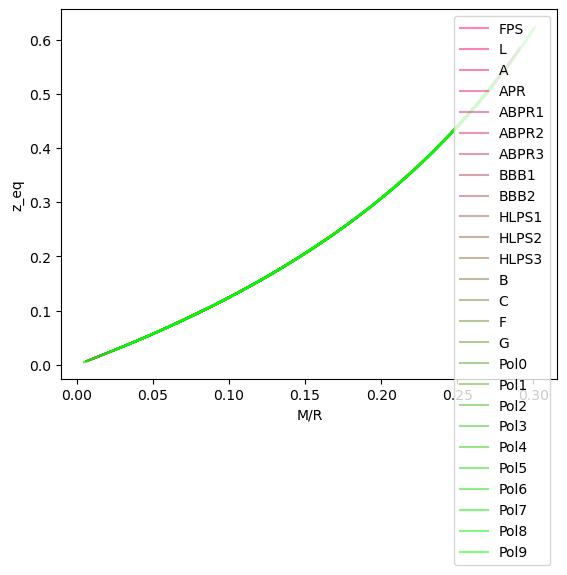

In [25]:
colors = np.linspace((1,0,0.5),(0,1,0),Eos_array.size)
i_r = 1
#for i_r in range(6):
c=0
for k in range(Eos_array.size):

    plt.plot(Eos_array[k].data[:, i_r, 4], Eos_array[k].data[:, i_r, 6], alpha=0.5, c=colors[c], label=Eos_array[k].name)
    plt.plot(Eos_array[k].data[:, i_r, 4], Eos_array[k].z_empirical(i_r, 0.3468)[1], alpha=0.5, c=colors[c])
    c+=1

plt.xlabel('M/R')
plt.ylabel("z_eq")
plt.legend()

In [31]:
def fit_LSQ_all(Eos_array, show=True):

    x = np.empty([0,2])
    y = np.empty([0])
    M = np.empty([0])
    omeg = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            mr = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 4]
            spn = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 5]
            z = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 6]
            Mfill = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 3]/Msun
            omegfill = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 1]/(2*np.pi)

            xfill = np.array([mr, mr**2]).transpose()
            yfill = (1/spn**2)*((1+z)*np.sqrt(1-2*mr)-1)

            x = np.concatenate([x, xfill])
            y = np.concatenate([y, yfill])
            M = np.concatenate([M, Mfill])
            omeg = np.concatenate([omeg, omegfill])

    xT = np.transpose(x)
    xTx = np.dot(xT, x)
    xTxinv = np.linalg.inv(xTx)
    A = np.dot(xTxinv, xT)
    coefs = np.dot(A, y)

    if (show):
        plt.scatter(x[:,0], y, s=2, c='b', alpha=0.3, label='data')
        xs = x[:,0]
        xs = np.sort(xs, None)
        plt.plot(xs, 1.2*xs**2+0.52*xs, c='r', lw=1.7, alpha=0.6, label='differential evolution')
        #plt.plot(xs, coefs[1]*xs**2+coefs[0]*xs, c='m', lw=1.7, alpha=0.6, label='LSQ fit')
        plt.plot(xs, 1/2*xs*(1+2*xs)*(1+0.3468*xs), c='k', lw=1.7, alpha=0.6, label='one parameter')
        plt.xlabel('M/R')
        plt.ylabel('$1/\overline{\Omega}^2 ((1+z)\sqrt{1-2M/R)}-1)$')
        plt.legend()

    plt.figure()
    plt.hist(xs, 30, rwidth=0.8)
    plt.xlabel("M/R")

    plt.figure()
    plt.hist(M, 30, rwidth=0.8)
    plt.xlabel("$M/M_\odot$")

    plt.figure()
    plt.hist(omeg, 30, rwidth=0.8)
    plt.xlabel("f (Hz)")
    
    return coefs

In [ ]:
fit_LSQ_all(Eos_array)

In [ ]:
fit_LSQ_all(Eos_real)

In [ ]:
fit_LSQ_all(Eos_poly)

In [42]:
def diff_evo_all_obj(params, Eos_array):

    c1 = params

    z_t = np.empty([0])
    z_e = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            mr = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 4]
            spn = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 5]

            z_t_fill = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 6]
            z_e_fill = (1/np.sqrt(1-2*mr))*(1+spn**2*(1/2*mr*(1+c1*mr)))-1

            z_t = np.concatenate([z_t, z_t_fill])
            z_e = np.concatenate([z_e, z_e_fill])

    residual = np.sum(((z_t-z_e)/(1+z_t))**2)

    return residual

def diff_evo_all(Eos_array):

    bounds = [(-5, 5),]
    result = differential_evolution(diff_evo_all_obj, bounds, args=(Eos_array,))
    c1 = result.x
    coefs = np.array([c1])

    return coefs

In [43]:
diff_evo_all(Eos_array)

array([[2.51480458]])

In [44]:
diff_evo_all(Eos_real)

array([[2.53339486]])

In [45]:
diff_evo_all(Eos_poly)

array([[2.50051008]])

In [36]:
def create_dataset(eos, e_min, e_max):
    ratios = r_ratios
    densities = np.linspace(e_min, e_max, N_dens)

    star_data = np.zeros([N_dens, N_spins, 10])
    i_r=0
    t_0 = time.time()
    for r in ratios:
        i_e = 0
        for e in densities:
            string = 'quasik.exe -f "../compose/eos' + eos + '" -e ' + "{:e}".format(e).replace('+', '') + ' -r ' + str(r)
            sub.run(string)
            output = np.loadtxt('star.csv', delimiter=',')
            star_data[i_e,i_r,:] = output
            print(eos+'  %i, %i ' % (i_r+1, i_e+1), end='\r')
            i_e += 1
        i_r += 1
    np.save('star_data_'+eos, star_data)
    t_f = time.time()
    t_min = round((t_f-t_0)/60, 2)
    print(eos+' done in '+str(t_min)+' minutes')
    return

In [41]:
create_dataset(eos_names[1], min_dens[1], max_dens[1])

C:\Users\James\AppData\Local\Temp\ipykernel_20648\2499753712.py:13: UserWarning: loadtxt: input contained no data: "star.csv"
  output = np.loadtxt('star.csv', delimiter=',')


ValueError: could not broadcast input array from shape (0,) into shape (10,)

In [38]:
for i in range(eos_names.size):
    try:
        create_dataset(eos_names[i], min_dens[i], max_dens[i])
    except ValueError:
        print(str(eos_names[i])+' failed due to ValueError')
    except TypeError:
        print(str(eos_names[i])+' failed due to TypeError')
    except Exception:
        print(str(eos_names[i])+' failed due to Exception')

C:\Users\James\AppData\Local\Temp\ipykernel_20648\2499753712.py:13: UserWarning: loadtxt: input contained no data: "star.csv"
  output = np.loadtxt('star.csv', delimiter=',')


APR failed due to ValueError
BBB failed due to ValueError
BLC failed due to ValueError
CMF1 failed due to ValueError
CMF1H failed due to ValueError
CMF2 failed due to ValueError
D1MStar failed due to ValueError
DD2Yd failed due to ValueError
DDHdY4 failed due to ValueError
DDMEX failed due to ValueError
GDFMI failed due to ValueError
GDFMII failed due to ValueError
GM1 failed due to ValueError
KDE0v failed due to ValueError
M3 failed due to ValueError
NL3 failed due to ValueError
PCSB2 failed due to ValueError
PKDD failed due to ValueError
QHC21A failed due to ValueError
QMCRMF3 failed due to ValueError
Rs failed due to ValueError
SK255 failed due to ValueError
Ska failed due to ValueError
TW failed due to ValueError
Pol0 failed due to ValueError
Pol1 failed due to ValueError
Pol2 failed due to ValueError
Pol3 failed due to ValueError


KeyboardInterrupt: 

In [ ]:
# c2 = 1.1*c1-0.55*c1^2